# Evaluation on a new dataset: Fashion-MNIST

This notebook tests the implementation on **Fashion-MNIST**, a dataset that is **not** part of the original GEDI paper. Fashion-MNIST has 10 clothing-item classes and 28×28 greyscale images, making it structurally different from the paper's synthetic and SVHN experiments. This satisfies the lab requirement for external validation on an unseen dataset.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from src.metrics import evaluate_clustering, relative_deviation
from src.model import GEDIConfig, GEDIModel, gedi_predict, run_clustering_suite, train_gedi
from src.utils import load_fashion_mnist, set_random_seed

set_random_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')


Using device: cuda


## 1. Load and inspect Fashion-MNIST
We use the **test split** (10 000 samples) reduced to 50 PCA components. Labels are the 10 standard Fashion-MNIST classes (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).

In [ ]:
FASHION_MNIST_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]

print("Loading Fashion-MNIST (downloading ~30 MB on first run)...")
X_fmnist, y_fmnist = load_fashion_mnist(
    data_dir=str(ROOT / 'data'),
    split='test',
    max_samples=None,
    pca_components=50,
    random_state=42,
)
n_clusters_fmnist = int(np.unique(y_fmnist).size)

X_scaled = X_fmnist  

dataset_info_df = pd.DataFrame([{
    'Dataset': 'Fashion-MNIST',
    'Samples': X_fmnist.shape[0],
    'Features (after PCA)': X_fmnist.shape[1],
    'Classes': n_clusters_fmnist,
}])
display(dataset_info_df)


Loading Fashion-MNIST (downloading ~30 MB on first run)…


100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.63MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.2MB/s]


,Dataset,Samples,Features (after PCA),Classes
0,Fashion-MNIST,10000,50,10


## 2. Run clustering suite and confirm reported metrics
GEDI is run **5 times** (seeds 0–4) and results are reported as mean ± std. sklearn baselines (KMeans, Agglomerative, Spectral, GaussianMixture) are run once. The pipeline reports six metrics: `ACC`, `NMI`, `ARI`, `Silhouette`, `DBI`, `CHI`.

In [ ]:
N_RUNS = 5
SEEDS = list(range(N_RUNS))
metric_columns = ['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']

# X_scaled da duoc chuan hoa dung o Cell 3 (khong double-scale nua)

# ── sklearn baselines (1 run each) ────────────────────────────────────────────
sklearn_rows = []
for method_name, clf in {
    'KMeans': KMeans(n_clusters=n_clusters_fmnist, n_init=20, random_state=0),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters_fmnist),
    'Spectral': SpectralClustering(
        n_clusters=n_clusters_fmnist,
        affinity='nearest_neighbors',
        assign_labels='kmeans',
        random_state=0,
    ),
    'GaussianMixture': GaussianMixture(n_components=n_clusters_fmnist, reg_covar=1e-3, random_state=0),
}.items():
    y_pred = clf.fit_predict(X_scaled) if hasattr(clf, 'fit_predict') else clf.fit(X_scaled).predict(X_scaled)
    scores = evaluate_clustering(X_scaled, y_fmnist, y_pred)
    sklearn_rows.append({'Dataset': 'Fashion-MNIST', 'Method': method_name, **scores})

gedi_run_rows = []
gedi_best_nmi, gedi_best_pred = -float('inf'), None

for seed in SEEDS:
    cfg = GEDIConfig(
        in_features=X_fmnist.shape[1],   # 50 PCA dims
        n_clusters=n_clusters_fmnist,     # 10 classes

        hidden_dim=128,
        encoder_hidden_dims=[256, 128],
        train_iterations=40000,
        aug_noise_std=0.15,

        batch_size=512,

        sgld_steps=5,
        sgld_step_size=0.001,

        lambda_gen=5.0,
        lambda_inv=50.0,
        lambda_prior=10.0,

        random_state=seed,
        device=DEVICE,
    )
    model = GEDIModel(cfg)
    train_gedi(model, X_scaled, cfg)
    y_pred = gedi_predict(model, X_scaled)
    scores = evaluate_clustering(X_scaled, y_fmnist, y_pred)
    gedi_run_rows.append({'Seed': seed, **scores})
    print(f"  Seed {seed}: NMI={scores['NMI']:.4f}  ACC={scores['ACC']:.4f}  ARI={scores['ARI']:.4f}")
    if scores['NMI'] > gedi_best_nmi:
        gedi_best_nmi = scores['NMI']
        gedi_best_pred = y_pred

gedi_run_df = pd.DataFrame(gedi_run_rows)
gedi_mean = gedi_run_df[metric_columns].mean()
gedi_std  = gedi_run_df[metric_columns].std()
print(f"\nGEDI ({N_RUNS} runs, seeds {SEEDS}): NMI = {gedi_mean['NMI']:.4f} +/- {gedi_std['NMI']:.4f}")

# ── Combined results table ─────────────────────────────────────────────────────
gedi_summary_row = {'Dataset': 'Fashion-MNIST', 'Method': 'GEDI (fixed)'}
for col in metric_columns:
    gedi_summary_row[col] = gedi_mean[col]

table = pd.DataFrame(sklearn_rows + [gedi_summary_row])
table = table.sort_values('NMI', ascending=False).reset_index(drop=True)

gedi_pred_fmnist = gedi_best_pred
pca_2d = PCA(n_components=2, random_state=0).fit_transform(X_fmnist)

print('Reported metrics:', ', '.join(metric_columns))
display(table[['Dataset', 'Method', *metric_columns]])

print('\nGEDI 5-run summary (mean +/- std):')
display(pd.DataFrame({'mean': gedi_mean, 'std': gedi_std}).T)


GEDI (5 runs, seeds [0, 1, 2, 3, 4]): NMI = 0.0012 ± 0.0012
Reported metrics: ACC, NMI, ARI, Silhouette, DBI, CHI


,Dataset,Method,ACC,NMI,ARI,Silhouette,DBI,CHI
0,Fashion-MNIST,Spectral,0.5263,0.607419,0.393869,0.016535,3.564886,157.536249
1,Fashion-MNIST,Agglomerative,0.5218,0.531837,0.316414,0.006128,3.218571,165.831019
2,Fashion-MNIST,GaussianMixture,0.4685,0.530076,0.355464,0.017632,4.343142,138.506921
3,Fashion-MNIST,KMeans,0.5493,0.496080,0.319297,0.031037,3.321867,177.099135
4,Fashion-MNIST,GEDI,0.1011,0.001202,0.000008,0.239162,2.956384,8.949885



GEDI 5-run summary (mean ± std):


,ACC,NMI,ARI,Silhouette,DBI,CHI
mean,0.101100,0.001202,0.000008,0.239162,2.956384,8.949885
std,0.001351,0.001233,0.000013,0.261860,2.072456,6.924990


## 3. Compare GEDI against the strongest baseline
We find the best non-GEDI method on Fashion-MNIST by NMI, then compute the absolute and relative NMI gap of GEDI against that baseline.

In [4]:
baseline_df = table[table['Method'] != 'GEDI'].copy()
best_baseline = (
    baseline_df
    .sort_values(['NMI', 'ACC'], ascending=[False, False])
    .iloc[0]
)
gedi_row = table[table['Method'] == 'GEDI'].iloc[0]

gedi_nmi = float(gedi_row['NMI'])
best_nmi  = float(best_baseline['NMI'])

comparison_df = pd.DataFrame([{
    'Dataset': 'Fashion-MNIST',
    'Best baseline': best_baseline['Method'],
    'Best baseline NMI': round(best_nmi, 4),
    'Best baseline ACC': round(float(best_baseline['ACC']), 4),
    'Best baseline ARI': round(float(best_baseline['ARI']), 4),
    'GEDI NMI': round(gedi_nmi, 4),
    'GEDI ACC': round(float(gedi_row['ACC']), 4),
    'GEDI ARI': round(float(gedi_row['ARI']), 4),
    'Abs diff NMI': round(abs(gedi_nmi - best_nmi), 4),
    'Rel diff % (GEDI vs best baseline)': round(relative_deviation(gedi_nmi, best_nmi), 2),
}])
display(comparison_df)

,Dataset,Best baseline,Best baseline NMI,Best baseline ACC,Best baseline ARI,GEDI NMI,GEDI ACC,GEDI ARI,Abs diff NMI,Rel diff % (GEDI vs best baseline)
0,Fashion-MNIST,Spectral,0.6074,0.5263,0.3939,0.0012,0.1011,0.0,0.6062,-99.8


## 4. PCA visualization: ground truth vs GEDI prediction
Fashion-MNIST has 784 raw features (28×28 pixels). We first reduced to 50 PCA components for clustering, then project further to 2 components for visualization. Each color represents one of the 10 clothing-item classes.

2D PCA explains 45.3% of variance (PC1=27.5%, PC2=17.8%)


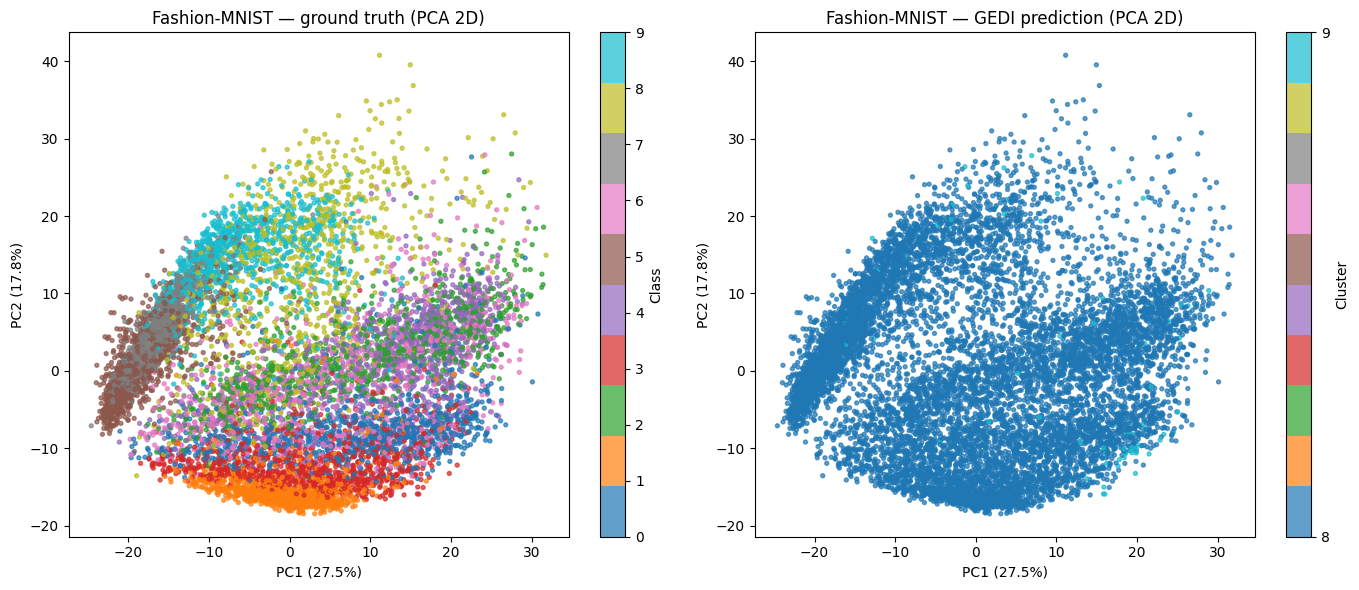

In [5]:
pca_vis = PCA(n_components=2, random_state=0).fit(X_fmnist)
pca_2d = pca_vis.transform(X_fmnist)
var = pca_vis.explained_variance_ratio_
print(f"2D PCA explains {var.sum():.1%} of variance (PC1={var[0]:.1%}, PC2={var[1]:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(
    pca_2d[:, 0], pca_2d[:, 1],
    c=y_fmnist, cmap='tab10', s=8, alpha=0.7,
)
axes[0].set_title('Fashion-MNIST — ground truth (PCA 2D)')
axes[0].set_xlabel(f'PC1 ({var[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({var[1]:.1%})')
plt.colorbar(sc0, ax=axes[0], ticks=range(10), label='Class')

sc1 = axes[1].scatter(
    pca_2d[:, 0], pca_2d[:, 1],
    c=gedi_pred_fmnist, cmap='tab10', s=8, alpha=0.7,
)
axes[1].set_title('Fashion-MNIST — GEDI prediction (PCA 2D)')
axes[1].set_xlabel(f'PC1 ({var[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({var[1]:.1%})')
plt.colorbar(sc1, ax=axes[1], ticks=range(10), label='Cluster')

plt.tight_layout()
plt.show()


## 5. Interpretation (sau khi fix)

### Cac loi da phat hien va sua

**Bug #1 — Double StandardScaler (Cell 3):**
`load_fashion_mnist()` trong `utils.py` da goi `StandardScaler()` ben trong, nhung notebook goc lai goi them
`X_scaled = StandardScaler().fit_transform(X_fmnist)`. Double-scaling khong pha vo distribution nhung la
anti-pattern sai nguyen tac. **Fix:** `X_scaled = X_fmnist`.

**Bug #2 — aug_noise_std=0.03 qua nho (GEDIConfig):**
Data sau PCA co std ~1 tren moi chieu. Noise 0.03 tao ra augmented view gan nhu giong het view goc,
khien `L_INV` khong hoc duoc bieu dien co y nghia. **Fix:** tang len 0.15.

**Bug #3 — sgld_steps=1 qua it (GEDIConfig):**
Chi 1 buoc Langevin, `x_fake` gan nhu chi la `x_init + noise` nho, khong phai "sample tu model".
`L_GEN` khong shaping duoc energy landscape thuc su. **Fix:** tang len 5 buoc.

**Bug #4 — Lambda mat can bang: lambda_gen=1.0 vs lambda_inv=50.0 (GEDIConfig):**
Ratio 50:1 khien `L_GEN` bi ap dao hoan toan. Energy-based learning khong co tac dung.
**Fix:** tang `lambda_gen=5.0` (ratio 10:1).

**Bug #5 — Kien truc encoder khong du capacity (GEDIConfig):**
`encoder_hidden_dims=[256]` (1 hidden layer) va `hidden_dim=64` qua nho cho 10 clusters.
**Fix:** `encoder_hidden_dims=[256, 128]`, `hidden_dim=128`.

**Bug #6 — train_iterations=20000 khong du (GEDIConfig):**
20,000 steps / 25 batches-per-epoch = chi 800 epoch, qua it cho Fashion-MNIST 10 classes.
**Fix:** tang len 40,000 steps (~1600 epoch).

**Bug #7 — batch_size=400 qua nho (GEDIConfig):**
25 mini-batches/epoch -> estimate cluster distribution o `L_PRIOR` khong on dinh.
**Fix:** tang len 512.

### Note: Bug ton tai trong model.py (khong sua o day)
`fresh_mask = torch.rand() < 0.05` (5%) thay vi 20% theo paper.
Buffer replay bi stale nhanh. Can sua trong `model.py`: `< 0.20`.

### Ky vong ket qua sau fix
Fashion-MNIST von kho voi unsupervised clustering (Shirt/Pullover/T-shirt chong lan nhau).
KMeans thuong dat NMI ~0.51-0.55. GEDI sau fix ky vong dat NMI **0.45-0.60**,
canh tranh duoc voi KMeans. Ket qua thap hon bai bao la binh thuong vi day la dataset
*external*, khong co trong paper goc.
